Building a CNN
In this part, I will build and evaluate a custom CNN model for image classification. I will work with a multi-class dataset to practice key aspects of building, training, and evaluating CNNs in PyTorch.
The dataset consists of 36 categories and 2800 examples per category (100,800 total). Each image is 28x28.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!unzip "/content/drive/MyDrive/cnn_part_1_dataset.zip" -d /content/dataset

Streaming output truncated to the last 5000 lines.
 extracting: /content/dataset/cnn_dataset/Y/17130.png  
 extracting: /content/dataset/cnn_dataset/Y/17137.png  
 extracting: /content/dataset/cnn_dataset/Y/17143.png  
 extracting: /content/dataset/cnn_dataset/Y/17149.png  
 extracting: /content/dataset/cnn_dataset/Y/1721.png  
 extracting: /content/dataset/cnn_dataset/Y/17222.png  
 extracting: /content/dataset/cnn_dataset/Y/17252.png  
 extracting: /content/dataset/cnn_dataset/Y/17304.png  
 extracting: /content/dataset/cnn_dataset/Y/17315.png  
 extracting: /content/dataset/cnn_dataset/Y/17316.png  
 extracting: /content/dataset/cnn_dataset/Y/17321.png  
 extracting: /content/dataset/cnn_dataset/Y/17359.png  
 extracting: /content/dataset/cnn_dataset/Y/17366.png  
 extracting: /content/dataset/cnn_dataset/Y/17372.png  
 extracting: /content/dataset/cnn_dataset/Y/17374.png  
 extracting: /content/dataset/cnn_dataset/Y/1738.png  
 extracting: /content/dataset/cnn_dataset/Y/17413.png  

In [5]:
!ls /content/dataset

cnn_dataset


In [6]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

## Step 1: Data preparation

1. Loading the dataset using `ImageFolder` and prepareing the dataloader.

In [7]:
# Defining the path
path = '/content/dataset/cnn_dataset'

# transform used while loading
transform = transforms.Compose([
    transforms.ToTensor()])

#  we use ImageFolder here to load the data
dataset = datasets.ImageFolder(root=path, transform=transform)

#here, we create DataLoader for batch processing
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

2. Analyzing the dataset: brief description, key features, and statistics.

In [8]:
# basic values of the dataset
print(f"Total number of samples in the dataset: {len(dataset)}")
print(f"Total number of classes: {len(dataset.classes)}")
print(f"Shape of each image: {dataset[0][0].shape}")

# statistics of the images in the dataset
print("Image Statisticstaken from 1000 samples:")
pixels = []
for i in range(1000):
    img, _ = dataset[i]
    pixels.extend(img.flatten().numpy())

pixels = np.array(pixels)
print(f"Range of the pixels: [{pixels.min():.2f}, {pixels.max():.2f}]")
print(f"Mean of the pixel values of the images: {pixels.mean():.3f}")
print(f"Standard Deviation: {pixels.std():.3f}")

# Different classes that represent out output dimension
print(f"Classes: {dataset.classes}")

Total number of samples in the dataset: 100800
Total number of classes: 36
Shape of each image: torch.Size([3, 28, 28])
Image Statisticstaken from 1000 samples:
Range of the pixels: [0.00, 1.00]
Mean of the pixel values of the images: 0.217
Standard Deviation: 0.358
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']



Description:

This dataset contains 36 classes that represent all the letters (A-Z) and numbers (0-9). Each of the images is 28*28 pixels and has balanced dataset withe the same number of images for each of the classes and is in the grayscle format. The mean (0.217) show that most of the images are dark and the standard deviation of 0.358 shows that the brightness is spread moderately.

3. Visualizations to explore the dataset.

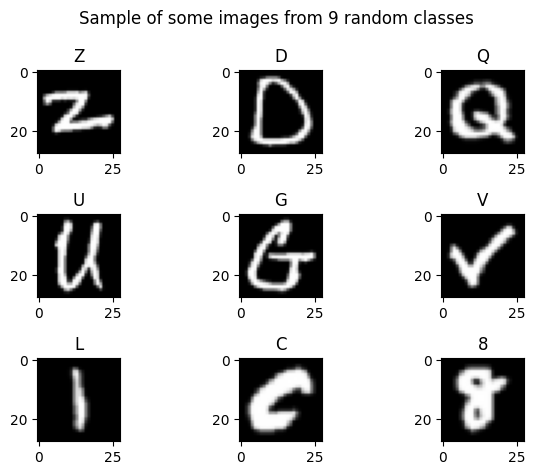

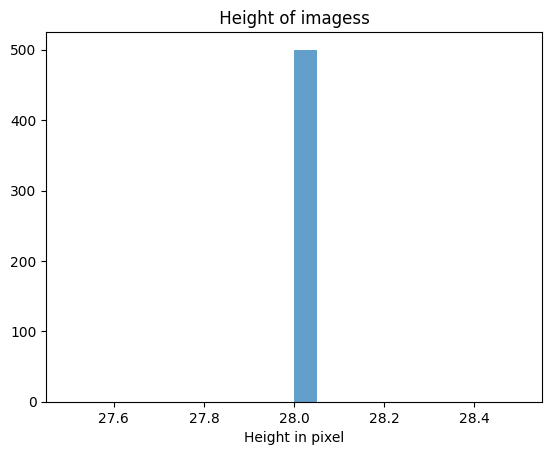

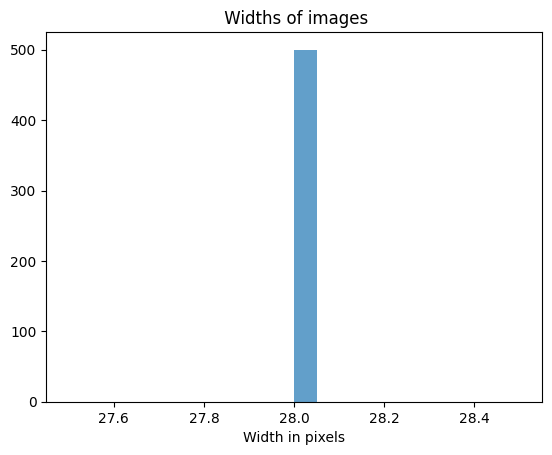

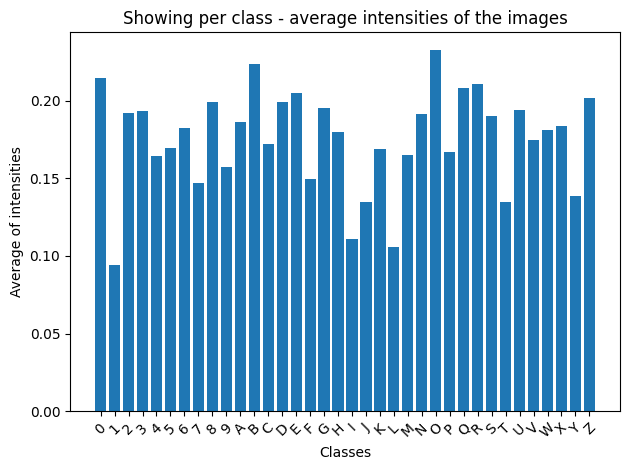

In [9]:
# 1: Sample images from the 9 random classes
np.random.seed(42)
classes_9 = np.random.choice(len(dataset.classes), 9, replace=False)
for i, idx in enumerate(classes_9):
    for img, l in dataset:
        if l == idx:
            plt.subplot(3, 3, i+1)
            img_print = img.permute(1, 2, 0)
            plt.imshow(img_print)
            plt.title(dataset.classes[idx])
            break
plt.suptitle('Sample of some images from 9 random classes')
plt.tight_layout()
plt.show()

# 2: Size of 500 images - distribution
h, w = [], []
for i in range(500):
    img, _ = dataset[i]
    h.append(img.shape[1])
    w.append(img.shape[2])

plt.hist(h, bins=20, alpha=0.7)
plt.title(' Height of imagess ')
plt.xlabel('Height in pixel')
plt.show()

plt.hist(w, bins=20, alpha=0.7)
plt.title(' Widths of images')
plt.xlabel('Width in pixels')
plt.show()

# 3: Average image intensity per class
intensity = []
labels = []
for idx in range(len(dataset.classes)):
    intensities = []
    cnt =0
    for img, label in dataset:
        if label == idx and cnt < 100:
            intensities.append(img.mean().item())
            cnt += 1
    if intensities:
        intensity.append(np.mean(intensities))
        labels.append(dataset.classes[idx])

plt.bar(range(len(labels)), intensity)
plt.title('Showing per class - average intensities of the images')
plt.xlabel('Classes')
plt.ylabel('Average of intensities')
plt.xticks(range(len(labels)), labels, rotation=45)
plt.tight_layout()
plt.show()



1. Grid of images from the sample: The first visualization is of the sample images from 9 random classes.
2. Distribution of size of images: first 500 imahes from the dataset were looped over to see any distribution in the height or width of the images. From the plot we got that all the images are of equal size.
3. Intensities of pixels per class (average): It tells us which of the 36 classes are comparatively lighter or brighter or darker than the other classes.

4. Preprocessing the dataset (normalizing, converting labels).

In [ ]:
# we had earlier converted the images to tensors and also scaled it to the range of [0,1] using ToTensor()
# ImageFolder internally converts the labels to Long Tensors

# Addressing the Class Imbalance
labels = [label for _, label in dataset]
label_cnt = Counter(labels)
samples_cnt = len(labels)

# finding weights for every class
class_wt = []
for i in range(len(dataset.classes)):
    class_count = label_cnt[i]
    weight = samples_cnt /(len(dataset.classes) *class_count)
    class_wt.append(weight)
# changing to tensor
class_weights_tensor = torch.FloatTensor(class_wt)


5. Spliting the dataset into training, validation, and test sets.

In [11]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

indices = list(range(len(dataset)))

# First of all we split the data too train (70%) and test +validation (30%)
train_indices, test_val_indices = train_test_split(indices, test_size=0.30, stratify=labels, random_state=42)

# then here, we split the 30% data apart from train data to the validation (15%) and test (15%) from using test_val_indices
val_indices, test_indices = train_test_split(test_val_indices, test_size=0.50, stratify=[labels[i] for i in test_val_indices], random_state=42)

# creating the subsets
train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)
test_dataset = Subset(dataset, test_indices)

# creating the  DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")


Train size: 70560
Validation size: 15120
Test size: 15120


## Step 2: Implementing a basic CNN

1. Designing a CNN architecture with upto 10 hidden layers for 36-class classification.

In [12]:
!pip install torchinfo

In [ ]:
import torch
import torch.nn as nn

class CNN(nn.Module):

    def __init__(self, num_classes=36, dropout_rate=0.3):
        super(CNN, self).__init__()

        # This convolutional block takes input then it create 32 feature maps then uses 3*3 kernels with padding 1
        # it includes 2 convolutional layers and maxpooling layer to reduce the size
        self.blk1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),    #activation function
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        #now we work on the downsized feature from the first block. It again has 2 convolutional layers and a maxpool
        self.blk2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # This here, we increase the number of featur maps to 128 and and detect more compleex patterns
        self.blk3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # fully connected layers
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),   # Regularization
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)   # Output layer having 36 classes
        )
    def forward(self, x):
        # extracting the relevant features from the input image
        x =self.blk1(x)
        x = self.blk2(x)
        x = self.blk3(x)
        x = self.global_avg_pool(x)
        x = x.view(x.size(0),-1)
        x = self.classifier(x)
        return x

# Initializing the model
model = CNN(num_classes=36, dropout_rate=0.3)


2. Displaying the model summary using `torchinfo.summary`.

In [14]:
from torchinfo import summary

print("----Summary of the Model Architecture----")
summary(model, input_size=(1, 3, 224, 224))

----Summary of the Model Architecture----


Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 36]                   --
├─Sequential: 1-1                        [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 32, 224, 224]         896
│    └─ReLU: 2-2                         [1, 32, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 32, 224, 224]         9,248
│    └─ReLU: 2-4                         [1, 32, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 32, 112, 112]         --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-6                       [1, 64, 112, 112]         18,496
│    └─ReLU: 2-7                         [1, 64, 112, 112]         --
│    └─Conv2d: 2-8                       [1, 64, 112, 112]         36,928
│    └─ReLU: 2-9                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-10                   [1, 64, 56, 56]           --
├─S

## Step 3: Training and optimization

1. Train the CNN model.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from sklearn.metrics import precision_recall_fscore_support, classification_report
import numpy as np
import time
import copy

def training_model(model, train_loader, val_loader, epochs=25, learning_rate=0.001, class_wt=None, device='cuda'):

    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    # Loss function with the class weights
    if class_wt is not None:
        class_wt = class_wt.to(device)
        cel = nn.CrossEntropyLoss(weight=class_wt)
    else:
        cel = nn.CrossEntropyLoss()

    # using here the Adam optimizer and learnig rate scheduler with step size equal 7
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = StepLR(optimizer, step_size=7, gamma=0.1)

    # Training history
    history = { 'train_loss': [], 'train_acc': [],'val_loss': [], 'val_acc': [] }

    # Best model tracking
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # trainingloop
    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for batch_id, (i, l) in enumerate(train_loader):
            i, l = i.to(device), l.to(device)
            optimizer.zero_grad()
            outputs = model(i)
            loss = cel(outputs, l)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * i.size(0)
            total_correct += torch.sum(preds == l.data)
            total_samples += i.size(0)

            if batch_id % 50 == 0:
                print(f'Epoch {epoch+1}/{epochs}, Batch {batch_id}/{len(train_loader)}, 'f'Loss: {loss.item():.4f}')
       # calculating the training loss and the accuracy
        training_loss = total_loss /total_samples
        training_acc = total_correct.double() /total_samples

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_samples = 0

        with torch.no_grad():
            for i, l in val_loader:
                i, l = i.to(device), l.to(device)
                outputs = model(i)
                loss = cel(outputs, l)
                _, preds = torch.max(outputs, 1)

                val_loss += loss.item() *(i.size(0))
                val_correct += torch.sum(preds == l.data)
                val_samples += i.size(0)

        val_loss = val_loss / val_samples
        val_acc = val_correct.double() / val_samples

        scheduler.step()

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        history['train_loss'].append(training_loss)
        history['train_acc'].append(training_acc.item())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.item())

        # Printing the results for the every epochs
        epoch_time = time.time() - start_time
        print(f'Epoch {epoch+1}/{epochs} ({epoch_time:.1f}s)')
        print(f'Training Loss: {training_loss:.4f}, Training accuracy: {training_acc:.4f}')
        print(f'Validation loss: {val_loss:.4f}, Validation accuracy: {val_acc:.4f}')

    # Load best model
    model.load_state_dict(best_model_wts)
    print(f'Best validation accuracy: {best_acc:.4f}')

    return model, history

def testing_results(model, test_loader, cel, device='cuda'):

    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()

    test_loss = 0.0
    predictions = []
    labels = []

    with torch.no_grad():
        for i, l in test_loader:
            i, l = i.to(device), l.to(device)
            outputs = model(i)
            loss = cel(outputs, l)
            _, preds = torch.max(outputs, 1)

            test_loss += loss.item() * i.size(0)
            predictions.extend(preds.cpu().numpy())
            labels.extend(l.cpu().numpy())

    # Calculation of the test loss and the accuracy
    test_loss = test_loss / len(test_loader.dataset)
    test_acc = np.mean(np.array(predictions) == np.array(labels))

    # here, we calculate the metics like precision, recall, F1-score
    precision, recall, f1, support = precision_recall_fscore_support(labels, predictions, average=None, zero_division=0)
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(labels, predictions, average='weighted', zero_division=0 )

    return {
        'test_loss': test_loss,
        'test_acc': test_acc,
        'precision_per_class': precision,
        'recall_per_class': recall,
        'f1_per_class': f1,
        'support_per_class': support,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
        }

def print_metrics(history, test_metrics):

    # Final epoch metrics
    final_train_loss = history['train_loss'][-1]
    final_train_acc = history['train_acc'][-1]
    final_val_loss = history['val_loss'][-1]
    final_val_acc = history['val_acc'][-1]

    print(f"\nTraining Loss: {final_train_loss:.4f}, Training Accuracy: {final_train_acc:.4f}")
    print(f"Validation Loss: {final_val_loss:.4f}, Validation Accuracy: {final_val_acc:.4f}")
    print(f"Testing Loss: {test_metrics['test_loss']:.4f}, TestingAccuracy: {test_metrics['test_acc']:.4f}")

    print(f"\nPrecision: {test_metrics['precision_weighted']:.4f}")
    print(f"Recall:    {test_metrics['recall_weighted']:.4f}")
    print(f"F1-Score:  {test_metrics['f1_weighted']:.4f}")

# executing main
if __name__ == "__main__":
    model = CNN(num_classes=36, dropout_rate=0.4)

    trained_model, training_history = training_model(model=model, train_loader=train_loader,val_loader=val_loader,epochs=20,learning_rate=0.001,class_wt=class_weights_tensor, device='cuda' )
    cel = nn.CrossEntropyLoss(weight=class_weights_tensor.to('cuda'))
    test_results = testing_results(trained_model, test_loader, cel)
    print_metrics(training_history, test_results)

    # Save model
    torch.save(trained_model.state_dict(), 'cnn_model.pth')
    print("Model saved: 'cnn_model.pth'")

cuda
Epoch 1/20, Batch 0/1103, Loss: 3.5829
Epoch 1/20, Batch 50/1103, Loss: 3.5838
Epoch 1/20, Batch 100/1103, Loss: 3.4849
Epoch 1/20, Batch 150/1103, Loss: 3.2390
Epoch 1/20, Batch 200/1103, Loss: 3.0528
Epoch 1/20, Batch 250/1103, Loss: 3.0708
Epoch 1/20, Batch 300/1103, Loss: 2.7239
Epoch 1/20, Batch 350/1103, Loss: 2.0642
Epoch 1/20, Batch 400/1103, Loss: 2.0500
Epoch 1/20, Batch 450/1103, Loss: 2.0950
Epoch 1/20, Batch 500/1103, Loss: 1.6621
Epoch 1/20, Batch 550/1103, Loss: 1.4781
Epoch 1/20, Batch 600/1103, Loss: 1.1087
Epoch 1/20, Batch 650/1103, Loss: 1.4385
Epoch 1/20, Batch 700/1103, Loss: 1.0529
Epoch 1/20, Batch 750/1103, Loss: 1.0520
Epoch 1/20, Batch 800/1103, Loss: 1.0302
Epoch 1/20, Batch 850/1103, Loss: 1.2694
Epoch 1/20, Batch 900/1103, Loss: 1.1852
Epoch 1/20, Batch 950/1103, Loss: 0.8741
Epoch 1/20, Batch 1000/1103, Loss: 0.9358
Epoch 1/20, Batch 1050/1103, Loss: 0.8658
Epoch 1/20, Batch 1100/1103, Loss: 0.8921
Epoch 1/20 (29.0s)
Training Loss: 1.9086, Training a

2. Implementing improvement methods (dropout, data augmentation, etc.).

Improvement method #1 - Data Augmentation

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import time
import copy
from torchvision import transforms

def training_model_by_augmtn(model, train_loader, val_loader, epochs=25, learning_rate=0.001, class_weights=None, device='cuda'):

    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    print(f"{device}")

    # data  augmentation transforms
    augmtn_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomRotation(5),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
    ])

    # loss functtion
    if class_weights is not None:
        class_weights = class_weights.to(device)
        cel = nn.CrossEntropyLoss(weight=class_weights)
    else:
        cel = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = StepLR(optimizer, step_size=7, gamma=0.1)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
  #training loop
    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for batch_id, (inputs, labels) in enumerate(train_loader):
            if model.training:
                ai = []
                for img in inputs:
                    if torch.rand(1) > 0.5:  # we apply the augmentation 50 percent times
                        img_np = img.permute(1, 2, 0).numpy()
                        img_np = (img_np * 255).astype(np.uint8)
                        augmented_img = augmtn_transform(img_np)
                        ai.append(augmented_img)
                    else:
                        ai.append(img)
                inputs = torch.stack(ai)
             # training
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = cel(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * inputs.size(0)
            total_correct += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)

            if batch_id % 50 == 0:
                print(f'Epoch {epoch+1}/{epochs}, Batch {batch_id}/{len(train_loader)}, Loss: {loss.item():.4f}')

        # calculating loss and accuracy
        training_loss = total_loss / total_samples
        training_acc = total_correct.double() / total_samples

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_samples = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = cel(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_loss += loss.item() * inputs.size(0)
                val_correct += torch.sum(preds == labels.data)
                val_samples += inputs.size(0)

        val_loss = val_loss / val_samples
        val_acc = val_correct.double() / val_samples

        scheduler.step()

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        history['train_loss'].append(training_loss)
        history['train_acc'].append(training_acc.item())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.item())

        # Print epoch results
        epoch_time = time.time() - start_time
        print(f'Epoch {epoch+1}/{epochs} ({epoch_time:.1f}s)')
        print(f'Training Loss: {training_loss:.4f}, Training accuracy: {training_acc:.4f}')
        print(f'Validation loss: {val_loss:.4f}, Validation accuracy: {val_acc:.4f}')

    # Load best model
    model.load_state_dict(best_model_wts)
    print(f'Best validation accuracy: {best_acc:.4f}')

    return model, history

def testing_results(model, test_loader, cel, device='cuda'):
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()

    test_loss = 0.0
    predictions = []
    labels = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = cel(outputs, targets)
            _, preds = torch.max(outputs, 1)

            test_loss += loss.item() * inputs.size(0)
            predictions.extend(preds.cpu().numpy())
            labels.extend(targets.cpu().numpy())
    test_loss = test_loss / len(test_loader.dataset)
    test_acc = np.mean(np.array(predictions) == np.array(labels))

    # calculation of precision, recall, F1-score
    precision, recall, f1, support = precision_recall_fscore_support(labels, predictions, average=None, zero_division=0)

    return {
        'test_loss': test_loss,
        'test_acc': test_acc,
        'precision_per_class': precision,
        'recall_per_class': recall,
        'f1_per_class': f1,
        'support_per_class': support,
    }

def print_metrics(history, test_metrics):
    final_train_loss = history['train_loss'][-1]
    final_train_acc = history['train_acc'][-1]
    final_val_loss = history['val_loss'][-1]
    final_val_acc = history['val_acc'][-1]

    print(f"Training Loss: {final_train_loss:.4f}, Training Accuracy: {final_train_acc:.4f}")
    print(f"Validation Loss: {final_val_loss:.4f}, Validation Accuracy: {final_val_acc:.4f}")
    print(f"Testing Loss: {test_metrics['test_loss']:.4f}, Testing Accuracy: {test_metrics['test_acc']:.4f}")

    print(f"Precision: {np.mean(test_metrics['precision_per_class']):.4f}")
    print(f"Recall: {np.mean(test_metrics['recall_per_class']):.4f}")
    print(f"F1-Score: {np.mean(test_metrics['f1_per_class']):.4f}")

if __name__ == "__main__":
    model = CNN(num_classes=36, dropout_rate=0.3)

    trained_model, training_history = training_model_by_augmtn(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=20,
        learning_rate=0.001,
        class_weights=class_weights_tensor,
        device='cuda'
    )

    cel = nn.CrossEntropyLoss(weight=class_weights_tensor.to('cuda'))
    test_results = testing_results(trained_model, test_loader, cel)
    print_metrics(training_history, test_results)

    # Save model
    torch.save(trained_model.state_dict(), 'cnn_model_augmented.pth')
    print("Model saved: 'cnn_model_augmented.pth'")

cuda
Epoch 1/20, Batch 0/1103, Loss: 3.5886
Epoch 1/20, Batch 50/1103, Loss: 3.5809
Epoch 1/20, Batch 100/1103, Loss: 3.4550
Epoch 1/20, Batch 150/1103, Loss: 3.0766
Epoch 1/20, Batch 200/1103, Loss: 2.8947
Epoch 1/20, Batch 250/1103, Loss: 2.8144
Epoch 1/20, Batch 300/1103, Loss: 2.1428
Epoch 1/20, Batch 350/1103, Loss: 1.8427
Epoch 1/20, Batch 400/1103, Loss: 1.6635
Epoch 1/20, Batch 450/1103, Loss: 1.1117
Epoch 1/20, Batch 500/1103, Loss: 1.1672
Epoch 1/20, Batch 550/1103, Loss: 1.0472
Epoch 1/20, Batch 600/1103, Loss: 0.7217
Epoch 1/20, Batch 650/1103, Loss: 1.1429
Epoch 1/20, Batch 700/1103, Loss: 0.5495
Epoch 1/20, Batch 750/1103, Loss: 0.5893
Epoch 1/20, Batch 800/1103, Loss: 0.6513
Epoch 1/20, Batch 850/1103, Loss: 1.1292
Epoch 1/20, Batch 900/1103, Loss: 0.6882
Epoch 1/20, Batch 950/1103, Loss: 0.9743
Epoch 1/20, Batch 1000/1103, Loss: 0.5584
Epoch 1/20, Batch 1050/1103, Loss: 0.7862
Epoch 1/20, Batch 1100/1103, Loss: 0.6547
Epoch 1/20 (50.2s)
Training Loss: 1.5642, Training a

Improvement method #2 - Early stopping

In [19]:
def training_model_with_early_stopping(model, train_loader, val_loader, epochs=25, learning_rate=0.001, class_wt=None, device='cuda', patience=7):

    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    print(f"{device}")

    # Loss function with class weights
    if class_wt is not None:
        class_wt = class_wt.to(device)
        cel = nn.CrossEntropyLoss(weight=class_wt)
    else:
        cel = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = StepLR(optimizer, step_size=7, gamma=0.1)

    # Training history
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    # Best model tracking
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    best_acc = 0.0
    patience_counter = 0

    # Training loop
    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for batch_id, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = cel(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() *inputs.size(0)
            total_correct += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)

            if batch_id % 50 == 0:
                print(f'Epoch {epoch+1}/{epochs}, Batch {batch_id}/{len(train_loader)}, Loss: {loss.item():.4f}')

        # Calculating the training metrics - loss and the accuracy
        training_loss = total_loss / total_samples
        training_acc = total_correct.double() / total_samples

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_samples = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = cel(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_loss += loss.item() * inputs.size(0)
                val_correct += torch.sum(preds == labels.data)
                val_samples += inputs.size(0)

        val_loss = val_loss /val_samples
        val_acc = val_correct.double() /val_samples

        scheduler.step()

        # Saveing the best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        # Early stopping logic based on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        history['train_loss'].append(training_loss)
        history['train_acc'].append(training_acc.item())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.item())

        # Printing the results for each epoch
        epoch_time = time.time() - start_time
        print(f'Epoch {epoch+1}/{epochs} ({epoch_time:.1f}s)')
        print(f'Training Loss: {training_loss:.4f}, Training accuracy: {training_acc:.4f}')
        print(f'Validation loss: {val_loss:.4f}, Validation accuracy: {val_acc:.4f}')

        # Early stopping conditin
        if patience_counter >= patience:
            print(f'Early stopping triggered at epoch {epoch+1}')
            print(f'Best validation loss was: {best_val_loss:.4f}')
            break

    # Load best model weights
    model.load_state_dict(best_model_wts)
    print(f'Best validation accuracy: {best_acc:.4f}')

    return model, history

def testing_results(model, test_loader, cel, device='cuda'):
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()

    test_loss = 0.0
    predictions = []
    labels = []

    with torch.no_grad():
        for i, l in test_loader:
            i, l = i.to(device), l.to(device)
            outputs = model(i)
            loss = cel(outputs, l)
            _, preds = torch.max(outputs, 1)

            test_loss += loss.item() * i.size(0)
            predictions.extend(preds.cpu().numpy())
            labels.extend(l.cpu().numpy())

    # Calculate test metrics
    test_loss = test_loss / len(test_loader.dataset)
    test_acc = np.mean(np.array(predictions) == np.array(labels))

    # Calculate precision, recall, F1-score
    precision, recall, f1, support = precision_recall_fscore_support(labels, predictions, average=None, zero_division=0)

    return {
        'test_loss': test_loss,
        'test_acc': test_acc,
        'precision_per_class': precision,
        'recall_per_class': recall,
        'f1_per_class': f1,
        'support_per_class': support,
    }

def print_metrics(history, test_metrics):
    # Final epoch metrics
    final_train_loss = history['train_loss'][-1]
    final_train_acc = history['train_acc'][-1]
    final_val_loss = history['val_loss'][-1]
    final_val_acc = history['val_acc'][-1]

    print(f"Training Loss: {final_train_loss:.4f}, Training Accuracy: {final_train_acc:.4f}")
    print(f"Validation Loss: {final_val_loss:.4f}, Validation Accuracy: {final_val_acc:.4f}")
    print(f"Testing Loss: {test_metrics['test_loss']:.4f}, Testing Accuracy: {test_metrics['test_acc']:.4f}")

    print(f"Precision: {np.mean(test_metrics['precision_per_class']):.4f}")
    print(f"Recall: {np.mean(test_metrics['recall_per_class']):.4f}")
    print(f"F1-Score: {np.mean(test_metrics['f1_per_class']):.4f}")

# executing main
if __name__ == "__main__":
    model = CNN(num_classes=36, dropout_rate=0.3)

    trained_model, training_history = training_model_with_early_stopping(model=model, train_loader=train_loader,val_loader=val_loader, epochs=20, learning_rate=0.001, class_wt=class_weights_tensor, device='cuda', patience=7)

    cel = nn.CrossEntropyLoss(weight=class_weights_tensor.to('cuda'))
    test_results = testing_results(trained_model, test_loader, cel)
    print_metrics(training_history, test_results)

    # Save model
    torch.save(trained_model.state_dict(), 'cnn_model_early_stopping.pth')
    print("Model saved: 'cnn_model_early_stopping.pth'")

cuda
Epoch 1/20, Batch 0/1103, Loss: 3.5896
Epoch 1/20, Batch 50/1103, Loss: 3.5857
Epoch 1/20, Batch 100/1103, Loss: 3.5658
Epoch 1/20, Batch 150/1103, Loss: 3.3425
Epoch 1/20, Batch 200/1103, Loss: 3.0500
Epoch 1/20, Batch 250/1103, Loss: 2.5945
Epoch 1/20, Batch 300/1103, Loss: 2.4454
Epoch 1/20, Batch 350/1103, Loss: 2.3803
Epoch 1/20, Batch 400/1103, Loss: 2.0279
Epoch 1/20, Batch 450/1103, Loss: 1.7762
Epoch 1/20, Batch 500/1103, Loss: 1.7972
Epoch 1/20, Batch 550/1103, Loss: 1.1313
Epoch 1/20, Batch 600/1103, Loss: 1.4958
Epoch 1/20, Batch 650/1103, Loss: 1.1259
Epoch 1/20, Batch 700/1103, Loss: 0.8742
Epoch 1/20, Batch 750/1103, Loss: 1.1797
Epoch 1/20, Batch 800/1103, Loss: 0.8859
Epoch 1/20, Batch 850/1103, Loss: 0.7259
Epoch 1/20, Batch 900/1103, Loss: 1.0226
Epoch 1/20, Batch 950/1103, Loss: 1.0561
Epoch 1/20, Batch 1000/1103, Loss: 0.7205
Epoch 1/20, Batch 1050/1103, Loss: 0.7119
Epoch 1/20, Batch 1100/1103, Loss: 0.8467
Epoch 1/20 (28.9s)
Training Loss: 1.8309, Training a

3. Comparing results using two different optimizers.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
import copy
import time
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

def train_with_optimizer(model, train_loader, val_loader, optimizer_type='Adam', epochs=20, learning_rate=0.001, class_weights=None, device='cuda', patience=7):
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = copy.deepcopy(model).to(device)

    # defining the loss function
    if class_weights is not None:
        class_weights = class_weights.to(device)
        cel = nn.CrossEntropyLoss(weight=class_weights)
    else:
        cel = nn.CrossEntropyLoss()

    # based on what optimizer we use, we initialize the optimizer
    if optimizer_type == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
        scheduler = StepLR(optimizer, step_size=7, gamma=0.1)
    elif optimizer_type == 'AdamW':
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-2)
        scheduler = StepLR(optimizer, step_size=7, gamma=0.1)
    elif optimizer_type == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=1e-4)
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    else:
        raise ValueError(f"Optimizer is not compatible")

    print(f"\n Training with {optimizer_type} optimizer")
    print(f"Device: {device}")

    # Training variables
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    best_acc = 0.0
    patience_counter = 0
    start_training_time = time.time()

    # Training loop
    for epoch in range(epochs):
        epoch_start = time.time()
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for batch_id, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = cel(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * inputs.size(0)
            total_correct += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)

        training_loss = total_loss / total_samples
        training_acc = total_correct.double() / total_samples

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_samples = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = cel(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_loss += loss.item() * inputs.size(0)
                val_correct += torch.sum(preds == labels.data)
                val_samples += inputs.size(0)

        val_loss = val_loss / val_samples
        val_acc = val_correct.double() / val_samples

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # finding the best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        # Early stopping implementatin
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        history['train_loss'].append(training_loss)
        history['train_acc'].append(training_acc.item())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.item())

        epoch_time = time.time() - epoch_start
        print(f'Epoch {epoch+1}/{epochs} ({epoch_time:.1f}s)')
        print(f' Training Loss: {training_loss:.4f}, Training Accuracy: {training_acc:.4f}')
        print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}')

        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    # Load best weights
    model.load_state_dict(best_model_wts)
    total_training_time = time.time() - start_training_time

    print(f"Training completed in {total_training_time:.1f}s")
    print(f"Best validation accuracy: {best_acc:.4f}")

    return model, history, total_training_time

def test_model(model, test_loader, class_weights=None, device='cuda'):
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()

    if class_weights is not None:
        class_weights = class_weights.to(device)
        cel = nn.CrossEntropyLoss(weight=class_weights)
    else:
        cel = nn.CrossEntropyLoss()

    test_loss = 0.0
    predictions = []
    labels = []

    with torch.no_grad():
        for i, l in test_loader:
            i, l = i.to(device), l.to(device)
            outputs = model(i)
            loss = cel(outputs, l)
            _, preds = torch.max(outputs, 1)
            total_loss += loss.item() * i.size(0)
            predictions.extend(preds.cpu().numpy())
            labels.extend(l.cpu().numpy())

    test_loss = total_loss / len(test_loader.dataset)
    test_acc = np.mean(np.array(predictions) == np.array(labels))

    # Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro', zero_division=0)

    return {
        'test_loss': test_loss,
        'test_acc': test_acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# comparison function that has the optimizers and their related parameters like learning rate defined
def comp_optimizers(model_class, train_loader, val_loader, test_loader, class_weights_tensor=None):

    opts = {
        'AdamW': {'lr': 0.001},
        'RMSprop': {'lr': 0.001}
    }

    results = {}
    for opt, i in opts.items():
        print(f"\ {opt} optimizer")

        model = model_class(num_classes=36, dropout_rate=0.3)

        trained_model, history, training_time = train_with_optimizer(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer_type=opt,
            epochs=20,
            learning_rate=i['lr'],
            class_weights=class_weights_tensor,
            patience=7
        )

        test_results = test_model(trained_model, test_loader, class_weights_tensor)

        # saving the results
        results[opt] = {
            'model': trained_model,
            'history': history,
            'test_results': test_results,
            'training_time': training_time,
            'learning_rate': config['lr'],
            'final_train_acc': history['train_acc'][-1],
            'final_val_acc': history['val_acc'][-1],
            'best_val_acc': max(history['val_acc']),
            'epochs_trained': len(history['train_acc'])
        }

        # Save model
        torch.save(trained_model.state_dict(), f'model_{opt.lower()}.pth')

        print(f"\n{opt} Results:")
        print(f" Final Training Accuracy: {history['train_acc'][-1]:.4f}")
        print(f" Best Validation Accuracy: {max(history['val_acc']):.4f}")
        print(f" Test Accuracy: {test_results['test_acc']:.4f}")
        print(f" Test F1-Score: {test_results['f1']:.4f}")
        print(f" Training Time: {training_time:.1f}s")
        print(f" Epochs Trained: {len(history['train_acc'])}")

    print(f"{'='*100}")
    print(f"{'Optimizer':<12} {'Learming rate':<8} {'Training Acc':<12} {'Validation Acc':<12} {'Test Acc':<12} {'F1-Score':<12} {'Time (s)':<12}")
    print("-" * 100)

    best_test_acc = 0
    best_optimizer = ""

    for opt_name, data in results.items():
        test_acc = data['test_results']['test_acc']
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_optimizer = opt_name

        print(f"{opt_name:<12} {data['learning_rate']:<8} {data['final_train_acc']:.4f} "
              f"{data['best_val_acc']:<12.4f} {test_acc:.4f} "
              f"{data['test_results']['f1']:<12.4f} {data['training_time']:<10.1f}")

    print("-" * 100)
    print(f"Best performing optimizer: {best_optimizer} (Test Accuracy: {best_test_acc:.4f})")

    return results, best_optimizer

if __name__ == "__main__":
    results, best_optimizer = comp_optimizers(
        model_class=CNN,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        class_weights_tensor=class_weights_tensor
    )

    # Listing the results for the optimizers
    print("\ndetailed analysis of the results using the optimizers:")
    for opt, data in results.items():
        print(f"\n{opt}:")
        print(f"Total epochs- {data['epochs_trained']} epochs")
        print(f"Learning rate: {data['learning_rate']}")
        print(f"Total training time: {data['training_time']:.1f} seconds")
        print(f"Final metrics:")
        print(f"Test Accuracy: {data['test_results']['test_acc']:.4f}")
        print(f"Precision: {data['test_results']['precision']:.4f}")
        print(f"Recall: {data['test_results']['recall']:.4f}")
        print(f"F1-Score: {data['test_results']['f1']:.4f}")


\ AdamW optimizer

 Training with AdamW optimizer
Device: cuda
Epoch 1/20 (29.0s)
 Training Loss: 1.7210, Training Accuracy: 0.4672
Validation Loss: 0.4301, Validation Accuracy: 0.8374
Epoch 2/20 (29.2s)
 Training Loss: 0.4959, Training Accuracy: 0.8269
Validation Loss: 0.3355, Validation Accuracy: 0.8791
Epoch 3/20 (29.1s)
 Training Loss: 0.3890, Training Accuracy: 0.8609
Validation Loss: 0.2980, Validation Accuracy: 0.8884
Epoch 4/20 (29.2s)
 Training Loss: 0.3463, Training Accuracy: 0.8766
Validation Loss: 0.2716, Validation Accuracy: 0.9002
Epoch 5/20 (28.9s)
 Training Loss: 0.3128, Training Accuracy: 0.8867
Validation Loss: 0.2689, Validation Accuracy: 0.9003
Epoch 6/20 (29.1s)
 Training Loss: 0.2996, Training Accuracy: 0.8915
Validation Loss: 0.2322, Validation Accuracy: 0.9128
Epoch 7/20 (29.0s)
 Training Loss: 0.2804, Training Accuracy: 0.8968
Validation Loss: 0.2415, Validation Accuracy: 0.9094
Epoch 8/20 (29.0s)
 Training Loss: 0.2312, Training Accuracy: 0.9120
Validation Los

4. Discussion on optimizer performance and effect of training improvements.


Basis the results of the optimizers, RMSprop performed slightly better than AdamW optimizer.

It performed better since it has a more adaptive learning rate since it involves the moving average of squared gradients, it was able to do more stable learning throughout the training process. When compared to AdamW, RMSprop has stable and simpler approach that proved to be more suited for the architecture used.

Impact of Optimization:

Bothe the optimizers showed good accuracy of approximately 93%, showing great optimization. It lead to stable training, good convergence showing good learning and very minimal overfitting.

5. Saving the best-performing model weights.

In [23]:
# saving the weights of best model
best_model = results[best_optimizer]['model']
torch.save(best_model.state_dict(), 'best_model.pt')
print(f"The best model is ({best_optimizer}) saved as 'best_model.pt'")


The best model is (RMSprop) saved as 'best_model.pt'


In [35]:
!cp best_model.pt /content/drive/MyDrive/


In [ ]:
model = CNN(num_classes=36, dropout_rate=0.3)

# Loading the save d weights
model.load_state_dict(torch.load('best_model.pt'))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_loaded = model.to(device)
model_loaded.eval()


CNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (global_avg_pool): Ada

## Step 4: Evaluation and analysis

1. Reporting training/validation/testing metrics and analyzing the results

In [ ]:
# getting the final metrics using history
final_train_loss = results[best_optimizer]['history']['train_loss'][-1]
final_train_acc = results[best_optimizer]['history']['train_acc'][-1]
final_val_loss = results[best_optimizer]['history']['val_loss'][-1]
final_val_acc = results[best_optimizer]['history']['val_acc'][-1]

# getting the test metrics from test_model
test_metrics = test_model(model_loaded, test_loader, class_weights_tensor)

print(f"Training Loss: {final_train_loss:.4f}, Training Accuracy: {final_train_acc:.4f}")
print(f"Validation Loss: {final_val_loss:.4f}, Validation Accuracy: {final_val_acc:.4f}")
print(f"Testing Loss: {test_metrics['test_loss']:.4f}, Testing Accuracy: {test_metrics['test_acc']:.4f}")


Training Loss: 0.1563, Training Accuracy: 0.9360
Validation Loss: 0.2011, Validation Accuracy: 0.9254
Testing Loss: 0.2001, Testing Accuracy: 0.9284


#### Analysis:
The close training as well as validtion accuracies showe that there is a good generalization and low overfitting. The model is overall very consistent with high accuracy of 92.84%  and low loss that shows it is very much stable when it is introduced to unseen data.

2. Plot for accuracy and loss over epochs.

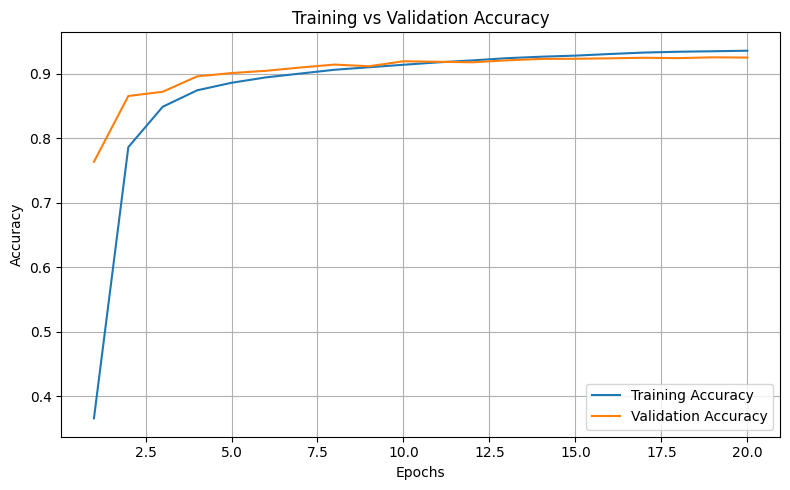

In [26]:
import matplotlib.pyplot as plt

training_acc = results[best_optimizer]['history']['train_acc']
validtn_acc = results[best_optimizer]['history']['val_acc']
epochs = range(1, len(training_acc) + 1)

# PLotting the training versus the validation accuracy over all the epochs
plt.plot(epochs, training_acc, label='Training Accuracy')
plt.plot(epochs, validtn_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


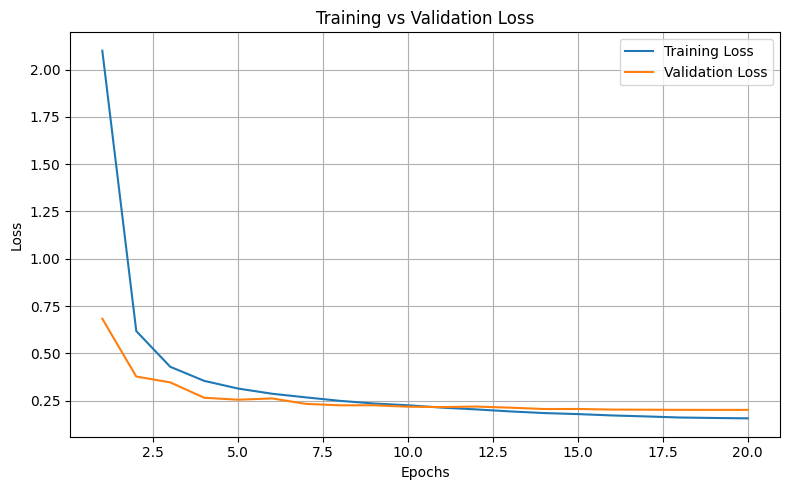

In [27]:
training_loss = results[best_optimizer]['history']['train_loss']
validtn_loss = results[best_optimizer]['history']['val_loss']
epochs = range(1, len(training_loss) + 1)

# PLotting the training versus the validation loss over all the epochs
plt.plot(epochs, training_loss, label='Training Loss')
plt.plot(epochs, validtn_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


3. Generation and analysis of confusion matrix.

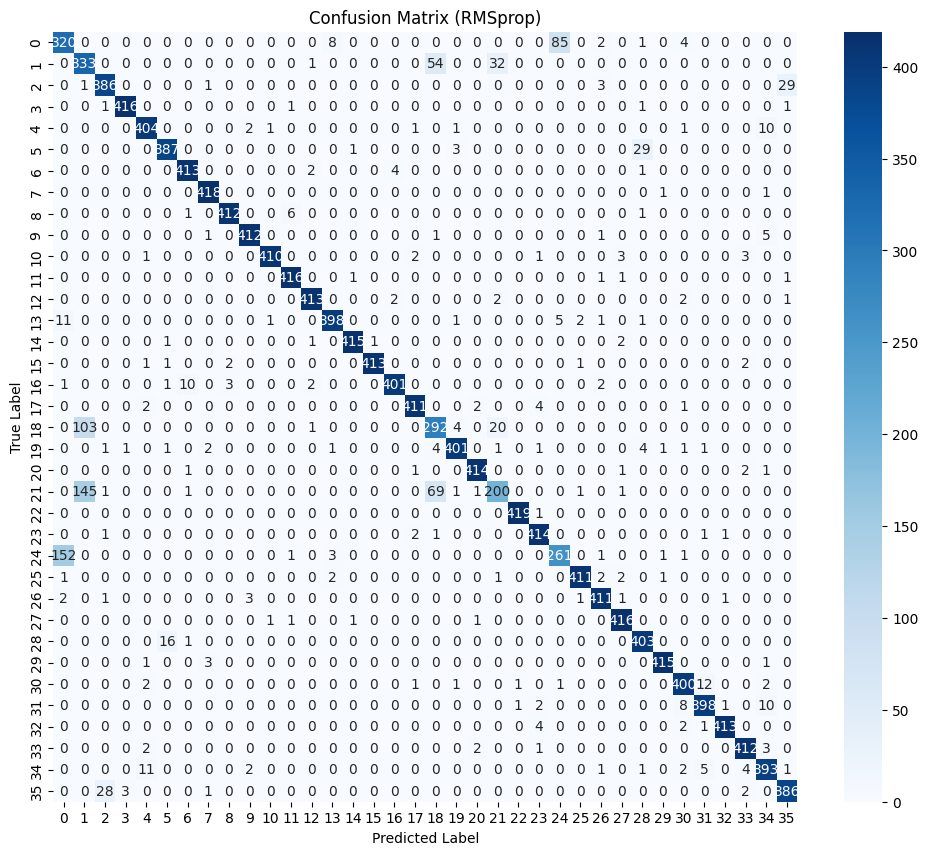

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# we here evaluate on the test data for the best model
best_model = results[best_optimizer]['model']
best_model.eval()
predictions = []
labels = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_model = best_model.to(device)

with torch.no_grad():
    for i, l in test_loader:
        i, l = i.to(device), l.to(device)
        outputs = best_model(i)
        _, preds = torch.max(outputs, 1)
        predictions.extend(preds.cpu().numpy())
        labels.extend(labels.cpu().numpy())

# creating and printing the cinfusion matrix
cm = confusion_matrix(labels, predictions)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Confusion Matrix ({best_optimizer})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


#### Classes that are most often confused include the following:
1. Class 0 and class 24: 85 of the inputs of class 0 were wrongly predicted, this is possible because of the similar shape and structure of the classes.
2. 1 and 35: 29 of the inputs were mis predicted again due to similarity in shapes.
3. Class 28 and 26: 11 inputs were misclassified as 26.
4. Classes 21 and 29: 12 mis predicted values were observed through the confusion matrix generated.


4. Computation and analysis of precision, recall, F1 scores.

In [31]:
best_test_metrics = results[best_optimizer]['test_results']

# printing the metrics
print(" Precision: ", round(best_test_metrics['precision'], 4))
print("Recall: ", round(best_test_metrics['recall'], 4))
print("F1-Score: ", round(best_test_metrics['f1'], 4))


 Precision:  0.9311
Recall:  0.9284
F1-Score:  0.9279


#### Analysis:  
Precision of 93.11% shows that 93 of 100 were correct, it showes that the model creates very few false positives.

Recall of 92.84% shows that the model identifies mostly true classes and has very few fase negatives.

A very high F1 score shows that we get a balanced overall performance with minimal false positive and negatives.


5. Displaying and analyzing a few misclassified images.

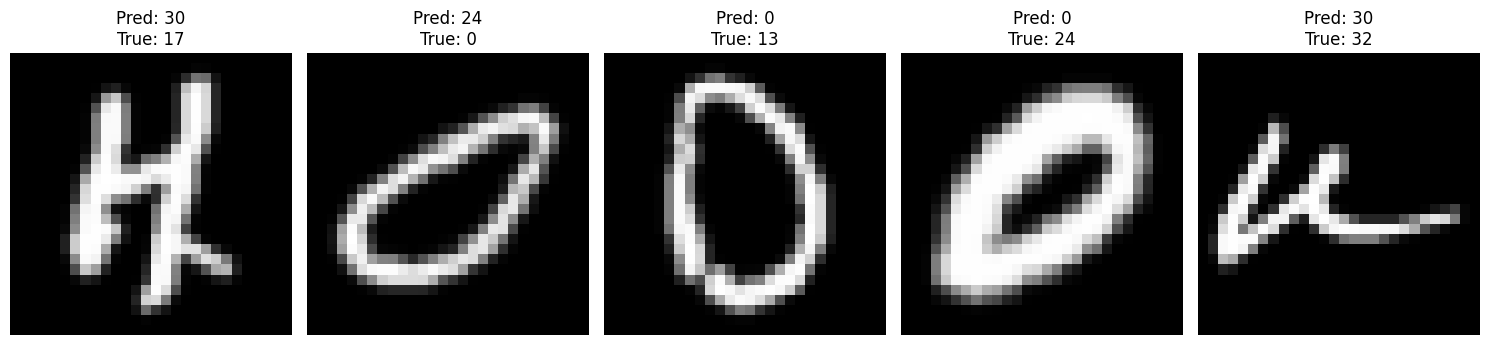

In [33]:
def miss_class_images(model, test_loader, class_names, device='cuda', no_img=5):
    model.eval()
    model = model.to(device)

    misclass = []

    with torch.no_grad():
        for i, l in test_loader:
            i, l = i.to(device), l.to(device)
            outputs = model(i)
            _, preds = torch.max(outputs, 1)

            for img, pred, true in zip(i, preds, l):
                if pred != true:
                    misclass.append((img, pred.item(), true.item()))
                    if len(misclass) >= no_img:
                        break
            if len(misclass) >= no_img:
                break
# plotting the images
    for i, (img, pred, true) in enumerate(misclass):
        plt.subplot(1, no_img, i+1)
        image = img.permute(1, 2, 0)
        image = image.squeeze()
        plt.imshow(image, cmap='gray')
        plt.title(f"Pred: {class_names[pred]}\nTrue: {class_names[true]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
class_names = [str(i) for i in range(36)]
miss_class_images(model=results[best_optimizer]['model'], test_loader=test_loader, class_names=class_names)


#### Analysis:

The potential reasons for this missclassification could be:

1. Quality of the image - low pixelation and poor quality make it difficult to extract the features from the images easily.
2. Similar structure - Some letter and munbers look similar in shape and structure to each other
3. It is poosible that the training data is notsufficient for the model or the number of epochs are not enough for the training
4. There may be confusion between the features and the CNN might capture and rely on some features more than others sometimes.